In [1]:
import pandas as pd
import numpy as np
import math
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import datetime
import warnings
import os
import pickle
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')
import matplotlib as mpl
warnings.filterwarnings("ignore")
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.size'] = 12

In [2]:
maturity = '10Y'
window_size = 373

In [3]:
load_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Data\Database_Regression.xlsx'
mergedData = pd.read_excel(load_path,index_col=[0],parse_dates=[0])
mergedData = mergedData.loc[datetime(2000,1,1):datetime(2025,1,1),[
    '2Yd','5Yd','10Yd','RN_2Yd','RN_5Yd','RN_10Yd','TP_2Yd','TP_5Yd','TP_10Yd',
    'SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd',
    'SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym',
    'OASd','EASurprise','USSurprise'
]]
mergedData.dropna(inplace=True)
    
diff_rates_clean = mergedData.loc[:,['2Yd','5Yd','10Yd',
                                     'RN_2Yd','RN_5Yd','RN_10Yd',
                                     'TP_2Yd','TP_5Yd','TP_10Yd',
                                     'SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]
diff_rates_clean.dropna(inplace=True)
z = np.abs(stats.zscore(diff_rates_clean))
threshold = 10

outliers = pd.concat([diff_rates_clean[z['2Yd']>threshold],diff_rates_clean[z['5Yd']>threshold],diff_rates_clean[z['10Yd']>threshold],
                      diff_rates_clean[z['RN_2Yd']>threshold],diff_rates_clean[z['RN_5Yd']>threshold],diff_rates_clean[z['TP_10Yd']>threshold],
                      diff_rates_clean[z['TP_2Yd']>threshold],diff_rates_clean[z['RN_5Yd']>threshold],diff_rates_clean[z['TP_10Yd']>threshold],
                      diff_rates_clean[z['SwapESTR2Yd']>threshold],diff_rates_clean[z['SwapESTR5Yd']>threshold],diff_rates_clean[z['SwapESTR10Yd']>threshold],
                      diff_rates_clean.loc[datetime(2023,3,13):datetime(2023,3,15)]],axis=0)

outliers.reset_index(inplace=True,drop=False)
outliers.drop_duplicates(subset='Date',inplace=True)
outliers.sort_values(by='Date',inplace=True,ignore_index=True)
outliers.set_index('Date',inplace=True,drop=True)

diff_rates_clean.drop(outliers.index,inplace=True,axis=0)

idx = diff_rates_clean.index

mergedData = mergedData.loc[idx]

In [4]:
diff_rates = mergedData.loc[:,['2Yd','5Yd','10Yd',
                               'TP_2Yd','TP_5Yd','TP_10Yd',
                               'RN_2Yd','RN_5Yd','RN_10Yd']]
    
ratevol_estr = mergedData.loc[:,['SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']].fillna(method='ffill').rolling(window=5,closed='left').std()
ratevol_estr = (ratevol_estr - ratevol_estr.mean())/ratevol_estr.std()
for j in ratevol_estr.columns:
    ratevol_estr.rename(columns={j: j.replace('Yd','Yv')},inplace=True)
    ratevol_estr.rename(columns={j: j.replace('Md','Mv')},inplace=True)

df_momentum_estr = mergedData.loc[:,['SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym']]
df_momentum_estr.fillna(method='ffill',inplace=True)
df_momentum_estr = (df_momentum_estr - df_momentum_estr.mean())/df_momentum_estr.std()

diff_oas = mergedData.loc[:,['OASd']]
diff_oas = (diff_oas - diff_oas.mean())/diff_oas.std()

df_surprise_ea = mergedData.loc[:,['EASurprise']]
df_surprise_ea = (df_surprise_ea - df_surprise_ea.mean())/df_surprise_ea.std()

df_surprise_us = mergedData.loc[:,['USSurprise']]
df_surprise_us = (df_surprise_us - df_surprise_us.mean())/df_surprise_us.std()

In [5]:
ea = pd.DataFrame()
us = pd.DataFrame()

if maturity == '2Y':
    rate = ['2Y','TP_2Y','RN_2Y']
if maturity == '5Y':
    rate = ['5Y','TP_5Y','RN_5Y']
if maturity == '10Y':
    rate = ['10Y','TP_10Y','RN_10Y']
    
for rate_reg in rate:
    df_reg = pd.concat([diff_rates.loc[:,[rate_reg+'d']],
                        df_surprise_ea,df_surprise_us,
                        df_momentum_estr.loc[:,['SwapESTR'+maturity+'m']],ratevol_estr.loc[:,['SwapESTR'+maturity+'v']],diff_oas],axis=1)
   
    Y = df_reg.iloc[:,[0]]
    X = df_reg.iloc[:,1:]
    X = sm.add_constant(X)
    
    reg_range = range(0,(len(Y)-window_size)-1,1)
    constant = list()
    constant_ub = list()
    constant_lb = list()
    surprise_ea = list()
    surprise_ea_ub = list()
    surprise_ea_lb = list()
    surprise_us = list()
    surprise_us_ub = list()
    surprise_us_lb = list()
    rsquared = list()
    reg_date = list()
    
    for i in reg_range:
        y = Y.iloc[i:(window_size+i)].astype(float)
        x = X.iloc[i:(window_size+i)].astype(float)
        model = sm.OLS(y, x, missing='drop').fit(cov_type='HAC',cov_kwds={'maxlags':math.ceil(0.75*len(y)**(1/3))})
        conf_int = model.conf_int(alpha=0.10)
        
        constant.append(model.params[0])
        constant_lb.append(conf_int.iloc[0,0])
        constant_ub.append(conf_int.iloc[0,1])
        
        surprise_ea.append(model.params[1])
        surprise_ea_lb.append(conf_int.iloc[1,0])
        surprise_ea_ub.append(conf_int.iloc[1,1])
        
        surprise_us.append(model.params[2])
        surprise_us_lb.append(conf_int.iloc[2,0])
        surprise_us_ub.append(conf_int.iloc[2,1])
        
        rsquared.append(model.rsquared)
        reg_date.append(Y.index[i+math.floor(window_size)])

    datemin = np.datetime64(reg_date[0])
    datemax = np.datetime64(reg_date[-1])
    fmt_major = mdates.YearLocator(2, month = 1, day = 1)
    fmt_minor = mdates.YearLocator(1, month = 1, day = 1)
    plt.rcParams['text.usetex'] = True
    
    ea = pd.concat([ea,pd.Series(surprise_ea_lb,index=reg_date),pd.Series(surprise_ea,index=reg_date),pd.Series(surprise_ea_ub,index=reg_date)],axis=1)
    us = pd.concat([us,pd.Series(surprise_us_lb,index=reg_date),pd.Series(surprise_us,index=reg_date),pd.Series(surprise_us_ub,index=reg_date)],axis=1)
   
ea.columns = ['Y_lb','Y','Y_ub','TP_lb','TP','TP_ub','RN_lb','RN','RN_ub']
us.columns = ['Y_lb','Y','Y_ub','TP_lb','TP','TP_ub','RN_lb','RN','RN_ub']

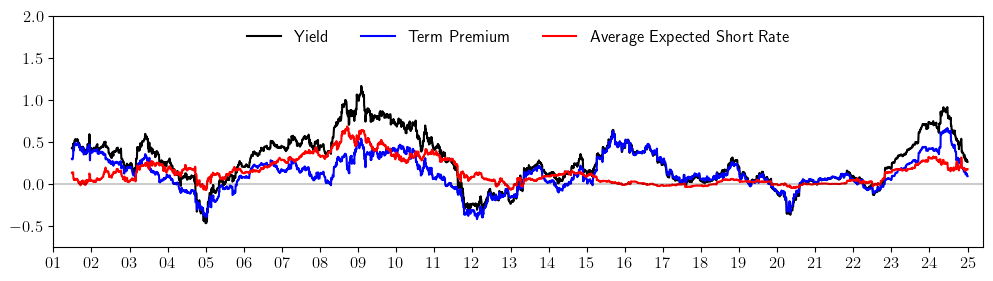

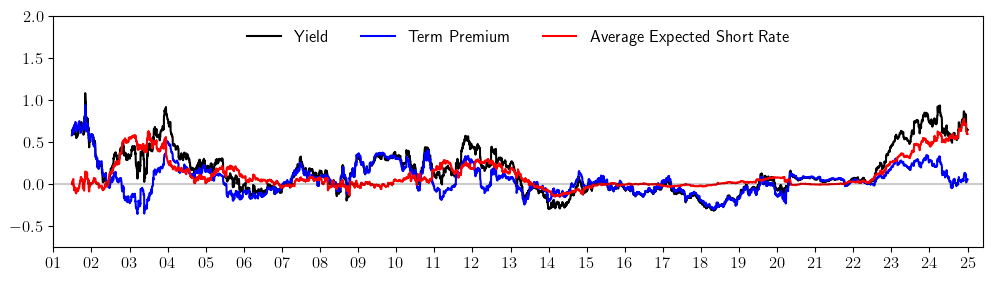

In [6]:
output_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output'
os.chdir(output_path)
fmt_major = mdates.YearLocator(1, month = 1, day = 1)
fmt_minor = mdates.YearLocator(1, month = 1, day = 1)

fig,ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(ea.index,ea.Y,color='k',label='Yield')
ax.plot(ea.index,ea.TP,color='blue',label='Term Premium')
ax.plot(ea.index,ea.RN,color='r',label='Average Expected Short Rate')
ax.set_ylim([-0.75,2])
ax.set_xlim([datetime(2001,1,1),datetime(2025,6,1)])
ax.axhline(0,color='k',alpha=.20)
ax.xaxis.set_major_locator(fmt_major)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.legend(loc='upper center',fancybox=False, shadow=False,frameon=False, ncol=3,fontsize=12)
if maturity == '2Y':
    plt.savefig('Decomposition2Y_EA',dpi=200,bbox_inches='tight')
if maturity == '5Y':
    plt.savefig('Decomposition5Y_EA',dpi=200,bbox_inches='tight')
if maturity == '10Y':
    plt.savefig('Decomposition10Y_EA',dpi=200,bbox_inches='tight')

fig,ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(us.index,us.Y,color='k',label='Yield')
ax.plot(us.index,us.TP,color='blue',label='Term Premium')
ax.plot(us.index,us.RN,color='r',label='Average Expected Short Rate')
ax.axhline(0,color='k',alpha=.20)
ax.set_ylim([-0.75,2])
ax.set_xlim([datetime(2001,1,1),datetime(2025,6,1)])
ax.xaxis.set_major_locator(fmt_major)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.legend(loc='upper center',fancybox=False, shadow=False,frameon=False, ncol=3,fontsize=12)
if maturity == '2Y':
    plt.savefig('Decomposition2Y_US',dpi=200,bbox_inches='tight')
if maturity == '5Y':
    plt.savefig('Decomposition5Y_US',dpi=200,bbox_inches='tight')
if maturity == '10Y':
    plt.savefig('Decomposition10Y_US',dpi=200,bbox_inches='tight')